In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
import matplotlib.patheffects as pe


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_eddies


,Day,Eddy,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1462,1,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000011,...,0.918433,-0.656814,1.558529,118.032741,47.992205,1.969122,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1463,1,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000018,...,1.537559,-0.243165,0.688838,108.004573,52.019741,1.602291,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1464,1,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000011,...,1.237644,-0.119636,0.819551,141.148836,74.035424,1.269457,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1465,1,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000016,...,1.404286,-0.325607,0.787603,111.650721,56.591801,1.544380,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1466,1,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000014,...,1.181141,-0.435550,1.007249,115.925719,57.471319,1.538338,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106155,10646,2826,CE,153.757172,-37.513498,182,61,518.287017,300.848692,-0.000026,...,1.036141,-0.109348,0.988587,91.984251,31.359836,1.138712,46.900904,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
106156,10647,2826,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,1.031585,0.002212,0.969387,78.707595,25.393893,1.031663,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
106157,10648,2826,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000026,...,1.010390,0.013422,0.989895,61.298208,19.369553,1.017029,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
106158,10649,2826,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000025,...,1.126718,-0.048147,0.889591,64.546558,19.604126,1.136121,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [12]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_AMEDA.pkl') # FROM 30 year and usign geostrophic velocities!!!!!!!!
df_ameda.rename(columns={'x1': 'lon', 'y1': 'lat'}, inplace=True)
points = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])
df_ameda[['xc', 'yc']] = griddata(
    points,
    np.column_stack([X_grid.ravel(), Y_grid.ravel()]),
    (df_ameda['lon'].values, df_ameda['lat'].values),
    method='linear'
)
df_ameda['Cyc'] = np.where(df_ameda.type == 1.0, 'CE', 'AE')
df_ameda['Day'] = (
    pd.to_datetime(df_ameda['step_datetime']) 
    - pd.Timestamp('1990-01-01')
).dt.days + 1 
df_ameda


,step,step_datetime,type,lon,lat,shapes1,eddy_id,calcul,large1,split,...,merge,merge2,shapes2,interaction,interaction2,eddy_local,xc,yc,Cyc,Day
0,1.0,1994-01-01,1.0,160.912245,-29.77283,"Path(array([[161.61770963, -29.48798766],\n ...",1,0.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0,914.419542,1346.871154,CE,1462
1,2.0,1994-01-02,1.0,160.949375,-29.688132,"Path(array([[161.65483933, -29.2660141 ],\n ...",1,0.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0,915.310762,1357.097000,CE,1463
2,3.0,1994-01-03,1.0,160.949375,-29.645783,"Path(array([[161.69196902, -29.26617934],\n ...",1,0.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0,914.029009,1361.587413,CE,1464
3,4.0,1994-01-04,1.0,160.949375,-29.603434,"Path(array([[161.69196902, -29.37183813],\n ...",1,0.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0,912.746308,1366.077551,CE,1465
4,5.0,1994-01-05,1.0,160.949375,-29.561085,"Path(array([[161.69196902, -29.35506344],\n ...",1,0.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0,911.463132,1370.567585,CE,1466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373372,10946.0,2023-12-20,-1.0,151.184266,-36.675719,"Path(array([[151.70408183, -36.38125238],\n ...",30848,0.0,1.0,NaN,...,NaN,NaN,"Path(array([[152.96649136, -36.4020328 ],\n ...",30730.0,NaN,1,272.948026,310.346358,AE,12407
373373,10947.0,2023-12-21,-1.0,151.258526,-36.675719,"Path(array([[150.85009891, -36.73661658],\n ...",30848,0.0,1.0,NaN,...,NaN,NaN,NaN,30730.0,NaN,1,279.225785,312.600751,AE,12408
373374,10948.0,2023-12-22,-1.0,151.369915,-36.591021,"Path(array([[152.07537875, -36.2340925 ],\n ...",30848,0.0,1.0,NaN,...,NaN,NaN,"Path(array([[152.96649136, -36.22881089],\n ...",30730.0,NaN,1,285.707619,324.795923,AE,12409
373375,10949.0,2023-12-23,-1.0,151.407044,-36.548672,"Path(array([[151.07287706, -36.66229721],\n ...",30848,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1,287.382598,330.331347,AE,12410


In [5]:
def day_plot(day, df_eddies, out_core_flag=False, center_flag=False):

    fnumber = 1461 + ((day - 1462) // 30)*30
    fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'
    with nc.Dataset(fname) as ds:
        ocean_time = ds['ocean_time'][:] / 86400
        t = np.where(ocean_time == day)[0][0]
        ut = ds['u_eastward'][t, -1, :, :].T
        vt = ds['v_northward'][t, -1, :, :].T

    df_day = df_eddies.loc[df_eddies.Day.eq(day)].copy()

    cs = np.hypot(ut, vt)

    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.pcolor(X_grid, Y_grid, cs, shading='nearest', vmin=0, vmax=2.5, cmap='Blues_r')
    fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

    clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')
    ax.scatter(df_day.xc, df_day.yc, c=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)

    if not center_flag: 
    
        if 'Q' not in df_day.columns:
            df_day['Q'] = list(
                np.stack([
                    np.stack([df_day.q11.values, df_day.q12.values], axis=1),
                    np.stack([df_day.q12.values, df_day.q22.values], axis=1)
                ], axis=1)
            )
    
        for xc, yc, e, Q, Rc, R, cyc in zip(df_day.xc, df_day.yc, df_day.Eddy, df_day.Q, df_day.Rc, df_day.R, df_day.Cyc):
    
            # ----- Where I plot the eddy's maximum tangenital velocity contour -----
            dx_ell, dy_ell = X_grid - xc, Y_grid - yc
            rho2_ell = Q[0,0]*dx_ell**2 + 2*Q[1,0]*dx_ell*dy_ell + Q[1,1]*dy_ell**2 # rho^2
            ax.contour(X_grid, Y_grid, rho2_ell, levels=[Rc**2/2], colors='r' if cyc=='AE' else 'c')
            ax.contour(X_grid, Y_grid, rho2_ell, levels=[(1.75*R)**2], linestyles='--', colors='r' if cyc=='AE' else 'c')
            # -----------------------------------------------------------------------
    
            ax.annotate(
                str(e), (xc, yc),
                textcoords='offset points', xytext=(3, 3),
                fontsize=12, color='w', weight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='k')],
                zorder=11
            )

    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
                
    ax.set_title(f'Day {day} | {pd.Timestamp("1990-01-01") + pd.Timedelta(days=day)}')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_xlim(x_grid.min(), x_grid.max())
    ax.set_ylim(y_grid.min(), y_grid.max())
    

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


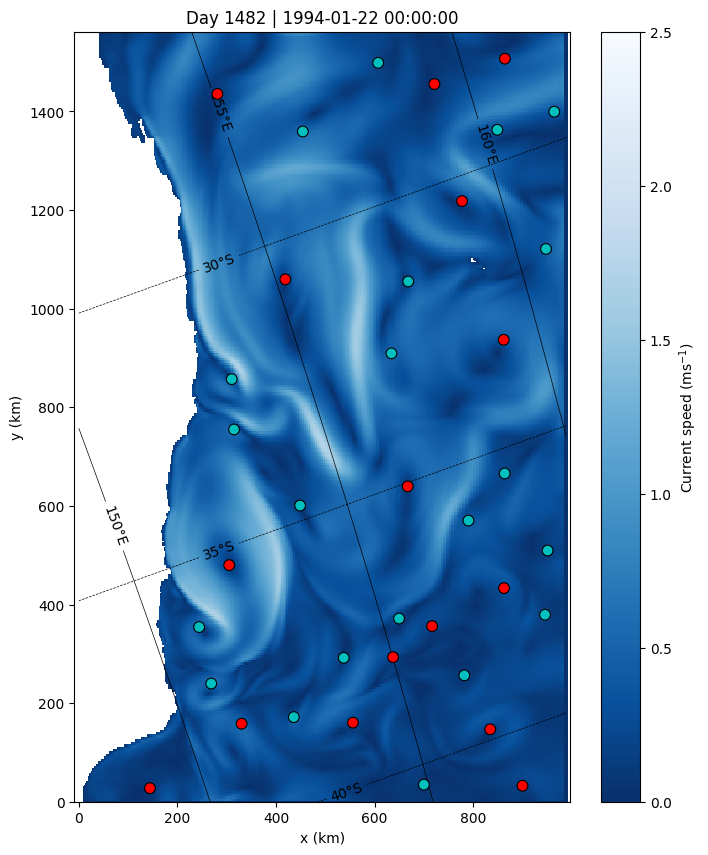

In [25]:
day_plot(1482, df_ameda, center_flag=True)
         

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


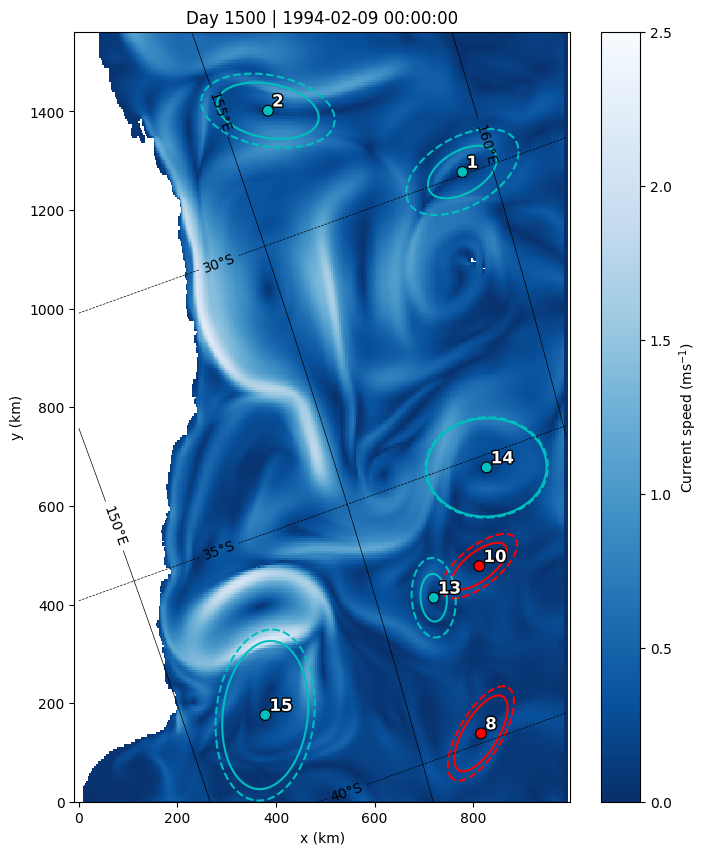

In [7]:
day_plot(1500, df_eddies, center_flag=False)
